### Measurement Oscilloscope Binary Dataformat

### Logbook 
- big_meas_sig_TestRun1... -> testing the ratio first before measurement (with signal) -> ~6.4% Ratio
- big_meas_sig_TestRun2... -> ~2% way too little
        -> visual check shows that the secoond setting also has way more disturbances
- big_meas_sig_TestRun3... -> ~5.7% and not so clean peaks
- big_meas_sig_TestRun4... -> diffractor very close but attenuator very low light -> ~5% still too low
- big_meas_sig_TestRun5... -> attenuator stronger light -> ~9% pretty good, peaks aren't too clean but probably good enough
- big_meas_sig_TestRun6... -> same as Run5 but 10_000 acq's -> jitter FWHM 0.07ns
- big_meas_sig_TestRun7... -> same as Run5 but 3ps resolution and manual window for storage, 60_000 acq's -> jitter  slightly worse FWHM 0.08ns

$\textcolor{red}{\text{Problem:}}$ the 1.6Gb size limit now seems to be enforced... 
-> trying new SCPI remote protocol to access Oscillator and make it output 200 files of 5_000 acquisitions -> see SCPI_remote_connection

with SCPI_remote_connection script wrote 200 files of 5000 acq's each into 1mio_events_sig folder numbered Run001, Run002...

-> signal data looks promising although slightly oversaturated 

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import pyarrow.parquet as pq
import time
import matplotlib.pyplot as plt
import argparse
import csv
import pyarrow as pa 

In [2]:
import pkgutil
[m.name for m in pkgutil.iter_modules() if "rtx" in m.name.lower()] # finding the module names

['RS_RTxReadBin_copy', 'RSRTxReadBin', 'RS_RTxReadBin']

In [3]:
import RS_RTxReadBin as rb  
from RS_RTxReadBin.RTxReadBin import RTxReadBin  
import os 

In [4]:
from functions_meas_finalcode import converter_binary_to_df

In [5]:
from functions_meas_finalcode import main_ratio_and_plots

In [6]:
from functions_meas_finalcode import main_jitter_plot_and_fwhm
from functions_meas_finalcode import main_amplitude_spectrum
from functions_meas_finalcode import main_main

In [35]:
filepath_sig = '/Users/laloscola/ExternalDrive/1mio_events_sig/Run_000.Wfm.bin' # from SCPI remote connection

In [36]:
df_sig = converter_binary_to_df(filepath_sig)

Found multichannel File, with channels: 1, 2. Using these!


Resolution -> 1e-12
RecordLength -> 20000.0
Number of Acquisitions: 5000
Timestamps recorded: Yes
Number of channels given: 2


In [37]:
from functions_meas_finalcode import plot_all_channels

In [ ]:
main_ratio_and_plots(df_sig, min_thresh=-0.01)

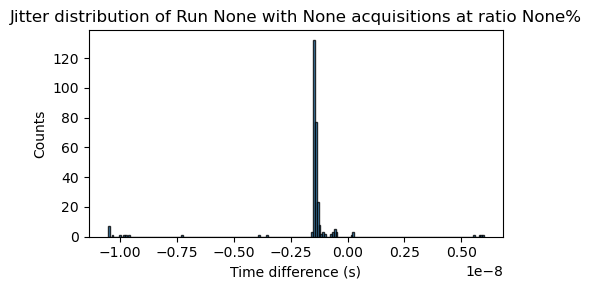

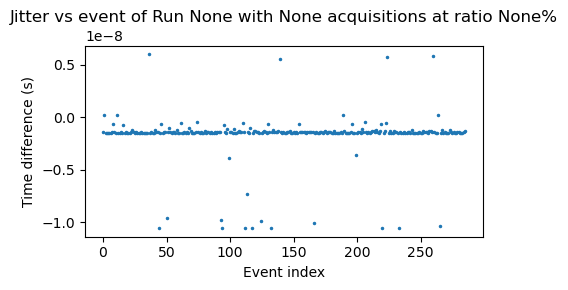

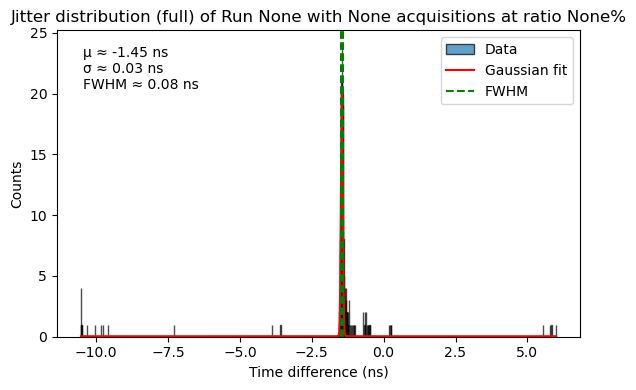

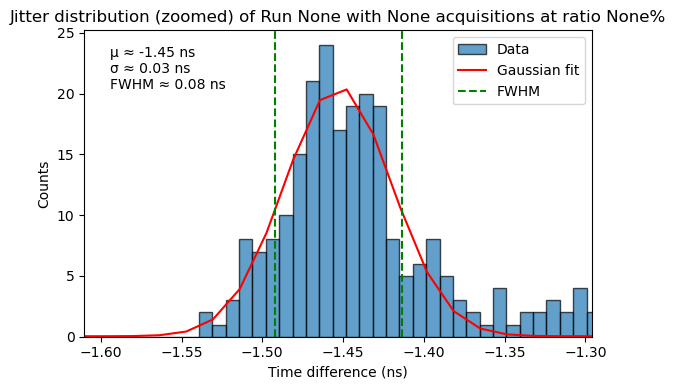

In [39]:
main_jitter_plot_and_fwhm(df_sig,bins_fit=2000)

The mean area is: 1.3065118013480628e-11 Vs


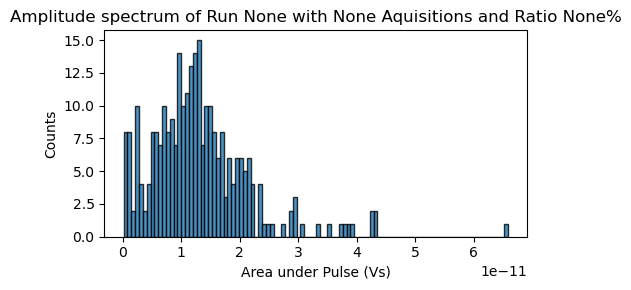

In [53]:
main_amplitude_spectrum(df_sig, min_thresh=-0.01)

$ \textcolor{green}{\textbf{Signal measurement successfull }} $

## Background measurement

### Logbook 
- put attenuator on maximum s.t. no light passes
- testing first ratiocheck_run_2025-12-16_0
    -> ratio of 0% at min_thresh=-0.01
    -> ratio of 0.02% at min_thresh=-0.008 (but the peaks look cleaner at -0.008)
  
--> starting measurement with SCPI controlling

In [54]:
filepath_bkg = '/Users/laloscola/ExternalDrive/1mio_events_bkg/Run_000.Wfm.bin'

In [55]:
df_bkg = converter_binary_to_df(filepath_bkg)

Found multichannel File, with channels: 1, 2. Using these!


Resolution -> 1e-12
RecordLength -> 20000.0
Number of Acquisitions: 5000
Timestamps recorded: Yes
Number of channels given: 2


In [56]:
main_ratio_and_plots(df_bkg, min_thresh=-0.008, show_only_camera=True)

There are: 0 interesting events, that match the used threshold
The percentage of interesting events to empty events is: 0.000%


0.0

In [ ]:
main_amplitude_spectrum(df_bkg, min_thresh= -0.002) # very slow, maybe use scipy integrate instead of trapezoidal integration 

-> good looking background for amplitude spectrum measurement